In [6]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import gaussian_kde
import tkinter as tk
from tkinter import filedialog
import warnings
from matplotlib.gridspec import GridSpec
import corner
import seaborn as sns
import itertools
from mpl_toolkits.mplot3d import Axes3D
warnings.filterwarnings('ignore')

In [4]:
def extraer_datos_de_carpetas(directorio_raiz):
    """
    Escanea la carpeta, extrae parámetros físicos del README y métricas del resumen,
    incluyendo conteos de zonas y áreas, blindado contra faltas de ortografía (tildes).
    """
    datos_recopilados = []
    print(f"\n🔍 Escaneando directorio: {directorio_raiz}...")
    
    for root, dirs, files in os.walk(directorio_raiz):
        resumen_file = None
        readme_file = None
        
        for file in files:
            if file.endswith(" resumen.txt") or file.endswith("_resumen.txt"):
                resumen_file = file
            elif file.startswith("README") and file.endswith(".txt"):
                readme_file = file
                
        if resumen_file and readme_file:
            nombre_planeta = os.path.basename(root).replace("_", " ")
            ruta_resumen = os.path.join(root, resumen_file)
            ruta_readme = os.path.join(root, readme_file)
            
            try:
                # 1. LEER RESUMEN (ZONAS Y ÁREAS)
                with open(ruta_resumen, 'r', encoding='utf-8') as f:
                    contenido_resumen = f.read()
                
                # Regex para ZONAS (Conteos Enteros)
                z_est_match = re.search(r'Total estables:\s*(\d+)', contenido_resumen)
                z_inest_match = re.search(r'Total inestables:\s*(\d+)', contenido_resumen)
                z_m1_match = re.search(r'Total colisi[oó]n m1:\s*(\d+)', contenido_resumen, re.IGNORECASE)
                z_m2_match = re.search(r'Total colisi[oó]n m2:\s*(\d+)', contenido_resumen, re.IGNORECASE)
                
                z_est = int(z_est_match.group(1)) if z_est_match else 0
                z_inest = int(z_inest_match.group(1)) if z_inest_match else 0
                z_m1 = int(z_m1_match.group(1)) if z_m1_match else 0
                z_m2 = int(z_m2_match.group(1)) if z_m2_match else 0
                
                # Regex para ÁREAS (Inmune a tildes)
                a_est_match = re.search(r'[AÁaá]rea estable:\s*([0-9.eE+-]+)', contenido_resumen)
                a_inest_match = re.search(r'[AÁaá]rea inestable:\s*([0-9.eE+-]+)', contenido_resumen)
                a_col_match = re.search(r'[AÁaá]rea.*colisi[oó]n.*m2:\s*([0-9.eE+-]+)', contenido_resumen, re.IGNORECASE)
                
                a_est = float(a_est_match.group(1)) if a_est_match else 0.0
                a_inest = float(a_inest_match.group(1)) if a_inest_match else 0.0
                a_col = float(a_col_match.group(1)) if a_col_match else 0.0
                
                # 2. LEER README (PARÁMETROS FÍSICOS)
                with open(ruta_readme, 'r', encoding='utf-8') as f:
                    contenido_readme = f.read()
                    
                dist_match = re.search(r'Semi-eje mayor.*:\s*([0-9.eE+-]+)', contenido_readme)
                masa_p_match = re.search(r'Masa del Planeta.*:\s*([0-9.eE+-]+)', contenido_readme)
                pnum_match = re.search(r'CANTIDAD DE PLANETAS.*:\s*(\d+)', contenido_readme)
                masa_e_match = re.search(r'Masa de.*estrella.*:\s*([0-9.eE+-]+)', contenido_readme, re.IGNORECASE)
                
                distancia = float(dist_match.group(1)) if dist_match else 0.0
                masa_planeta = float(masa_p_match.group(1)) if masa_p_match else 0.0
                pnum = int(pnum_match.group(1)) if pnum_match else 0
                masa_estel = float(masa_e_match.group(1)) if masa_e_match else 1.0
                
                datos_recopilados.append({
                    "Planeta": nombre_planeta,
                    "Distancia_UA": distancia,
                    "Masa_Tierra": masa_planeta,
                    "Masa_Estrella": masa_estel,
                    "Num_Planetas": pnum,
                    "Zonas Estables": z_est,             # <-- AQUÍ NACE LA COLUMNA
                    "Zonas Inestables": z_inest,
                    "Zonas Colisión m1": z_m1,
                    "Zonas Colisión m2": z_m2,
                    "Area_Estable_km2": a_est,
                    "Area_Inestable": a_inest,
                    "Area_Colision_m2": a_col
                })
            except Exception as e:
                print(f"❌ Error interno procesando {nombre_planeta}: {e}")
                
    df_resultados = pd.DataFrame(datos_recopilados)
    if not df_resultados.empty:
        df_resultados = df_resultados.sort_values(by="Planeta").reset_index(drop=True)
        print(f"✅ Lectura completada. Se extrajeron datos válidos de {len(df_resultados)} planetas.")
    return df_resultados

In [3]:
def graficar_comparacion_multiplicidad(df, base_dir):
    """
    Genera paneles verticales dinámicos graficando el CONTEO de Zonas Estables.
    """
    a_total = df['Distancia_UA'].values
    
    # --- LA CORRECCIÓN DEL KEYERROR ---
    areas = df['Zonas Estables'].values 
    pnum_total = df['Num_Planetas'].values
    
    # 1. Extraer el nombre del Sistema (Ej: "DMPP-1 b" -> "DMPP-1")
    df['Sistema'] = df['Planeta'].apply(lambda x: str(x).rsplit(' ', 1)[0])
    sistemas_unicos = df['Sistema'].unique()
    
    # 2. Generar combinaciones únicas de Marcadores y Colores para cada Sistema
    marcadores_base = ['o', 's', '^', 'D', 'v', 'p', '*', 'h', 'H', 'X', 'd', 'P', '<', '>']
    colores_base = plt.cm.tab20.colors
    combinaciones = itertools.product(marcadores_base, colores_base)
    
    estilos_sistema = {}
    for sist, (marker, color) in zip(sistemas_unicos, combinaciones):
        estilos_sistema[sist] = {'marker': marker, 'color': color}

    estilos_pnum = {
        1: {'marker': 'o', 'color': 'gray', 'label': '1 planeta'},
        2: {'marker': 's', 'color': '#4363d8', 'label': '2 planetas'},
        3: {'marker': '^', 'color': '#e6194b', 'label': '3 planetas'},
        4: {'marker': 'D', 'color': '#3cb44b', 'label': '4 planetas'},
        5: {'marker': 'v', 'color': '#f58231', 'label': '5 planetas'},
        6: {'marker': 'p', 'color': '#911eb4', 'label': '6 planetas'},
        7: {'marker': '*', 'color': '#f032e6', 'label': '7 planetas'},
        8: {'marker': 'h', 'color': '#bcbd22', 'label': '8 planetas'}
    }

    # 3. Determinar número de paneles dinámicamente
    pnums_unicos = sorted(df['Num_Planetas'].unique())
    num_paneles = len(pnums_unicos) + 1
    
    fig, axes = plt.subplots(num_paneles, 1, figsize=(14, 6 * num_paneles))
    fig.suptitle("Comparación de Zonas Estables por Multiplicidad", fontsize=22, fontweight='bold', y=0.98)
    
    if num_paneles == 1:
        axes = [axes]
        
    xlims = (a_total.min() * 0.5, a_total.max() * 2.0) if len(a_total) > 0 else (0.1, 100)
    # Ajuste de límites Y para conteos (evitar log(0) si hay ceros usando margen)
    ylims = (0.5, areas.max() * 2.0) if len(areas) > 0 and areas.max() > 0 else (0.5, 10000)

    # ==========================================
    # PANEL 0: General
    # ==========================================
    ax_all = axes[0]
    ax_all.set_title("Todos los sistemas (Clasificados por Multiplicidad)", fontsize=16, fontweight='bold')
    
    for p_num in pnums_unicos:
        mask = pnum_total == p_num
        props = estilos_pnum.get(p_num, {'marker': 'X', 'color': 'black', 'label': f'{p_num} planetas'})
        ax_all.scatter(a_total[mask], areas[mask], marker=props['marker'], color=props['color'], 
                       s=100, alpha=0.8, edgecolor='black', label=props['label'], zorder=3)
        
    ax_all.legend(loc='upper left', bbox_to_anchor=(1.02, 1), frameon=True, shadow=True, title="Simbología")

    # ==========================================
    # PANELES 1 al N: Filtros específicos
    # ==========================================
    for i, p_num in enumerate(pnums_unicos):
        ax = axes[i+1]
        df_sub = df[df['Num_Planetas'] == p_num]
        
        ax.set_title(f"Sistemas con {p_num} planetas", fontsize=16, fontweight='bold')
        
        # KDE de densidad sobre la Distancia (X)
        a_sub = df_sub['Distancia_UA'].values
        if len(a_sub) >= 2:
            log_a = np.log10(a_sub)
            try:
                kde = gaussian_kde(log_a)
                x_eval = np.linspace(log_a.min(), log_a.max(), 1000)
                y_eval = kde(x_eval)
                idx_max = np.argmax(y_eval)
                a_pico = 10**x_eval[idx_max]
                umbral = y_eval.max() * 0.5
                indices_rango = np.where(y_eval > umbral)[0]
                
                if len(indices_rango) > 0:
                    a_min_rango = 10**x_eval[indices_rango[0]]
                    a_max_rango = 10**x_eval[indices_rango[-1]]
                    texto_rango = f'Concentración: {a_min_rango:.2f} - {a_max_rango:.2f} UA'
                    ax.axvspan(a_min_rango, a_max_rango, color='gray', alpha=0.15, label=texto_rango, zorder=0)
                    ax.axvline(a_pico, color='red', linestyle=':', linewidth=1.5, label=f'Pico: {a_pico:.2f} UA', zorder=1)
            except np.linalg.LinAlgError:
                pass 

        # Trazar puntos de sistemas
        sistemas_en_este_panel = df_sub['Sistema'].unique()
        for sist in sistemas_en_este_panel:
            df_sist = df_sub[df_sub['Sistema'] == sist]
            props = estilos_sistema[sist]
            
            ax.scatter(df_sist['Distancia_UA'], df_sist['Zonas Estables'], 
                       marker=props['marker'], color=props['color'], 
                       s=110, alpha=0.85, edgecolor='black', label=sist, zorder=3)
        
        ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), frameon=True, 
                  shadow=True, title="Nombre del Sistema", ncol=2, fontsize=9)

    # ESTÉTICA DE EJES
    for ax in axes:
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlim(xlims)
        ax.set_ylim(ylims)
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:g}'))
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:g}'))
        
        ax.grid(True, which="both", ls="--", alpha=0.3, zorder=0)
        ax.set_xlabel("log[a] (UA)", fontsize=12, fontweight='bold')
        ax.set_ylabel("log[Zonas Estables] (Conteo)", fontsize=12, fontweight='bold') # ETIQUETA CORREGIDA

    plt.tight_layout(rect=[0, 0.03, 0.85, 0.98]) 
    
    ruta_png = os.path.join(base_dir, "Zonas_Estables_Multiplicidad_Vertical.png")
    ruta_pdf = os.path.join(base_dir, "Zonas_Estables_Multiplicidad_Vertical.pdf")
    plt.savefig(ruta_png, dpi=300, bbox_inches='tight')
    plt.savefig(ruta_pdf, format="pdf", bbox_inches='tight')
    plt.show()
    plt.close()

In [2]:
def plot_islands_multi_zonas(df, base_dir):
    """
    Genera mapas de contornos de densidad 2D (KDE) verticales iterando
    automáticamente sobre los 4 parámetros de zonas dinámicas.
    """
    # 1. Definir los parámetros a iterar
    metricas = [
        "Zonas Estables", 
        "Zonas Inestables", 
        "Zonas Colisión m1", 
        "Zonas Colisión m2"
    ]

    # 2. Extraer el nombre del Sistema (Ej: "DMPP-1 b" -> "DMPP-1")
    if 'Sistema' not in df.columns:
        df['Sistema'] = df['Planeta'].apply(lambda x: str(x).rsplit(' ', 1)[0])
        
    sistemas_unicos = df['Sistema'].unique()
    
    # 3. Generar combinaciones únicas de Marcadores y Colores para cada Sistema
    marcadores_base = ['o', 's', '^', 'D', 'v', 'p', '*', 'h', 'H', 'X', 'd', 'P', '<', '>']
    colores_base = plt.cm.tab20.colors # 20 colores distintos
    combinaciones = itertools.product(marcadores_base, colores_base)
    
    estilos_sistema = {}
    for sist, (marker, color) in zip(sistemas_unicos, combinaciones):
        estilos_sistema[sist] = {'marker': marker, 'color': color}

    # ==========================================
    # BUCLE PRINCIPAL: 1 Figura por cada Métrica
    # ==========================================
    for metrica in metricas:
        print(f"Generando mapa de contornos 2D expandido para: {metrica}...")
        
        # Filtrar datos con valores > 0 para evitar log(0) en los pesos del KDE
        df_f = df[df[metrica] > 0].copy()
        
        if df_f.empty or len(df_f) < 3:
            print(f"⚠️ No hay suficientes datos válidos (>0) para generar el mapa de {metrica}.")
            continue

        # 4. Determinar número de paneles para esta métrica
        pnums_unicos = sorted(df_f['Num_Planetas'].unique())
        num_paneles = len(pnums_unicos) + 1
        
        # Crear la figura vertical (Tamaño expandido)
        fig, axes = plt.subplots(num_paneles, 1, figsize=(18, 10 * num_paneles))
        fig.suptitle(f"Mapas de Contorno 2D: Islas de {metrica} por Multiplicidad", 
                     fontsize=24, fontweight='bold', y=0.98)
        
        if num_paneles == 1:
            axes = [axes]

        # Definir límites globales para compartir escala (Márgenes amplios de 0.4)
        x_all = np.log10(df_f['Distancia_UA'])
        y_all = np.log10(df_f['Masa_Tierra'])
        xlims = (x_all.min() - 0.4, x_all.max() + 0.4)
        ylims = (y_all.min() - 0.4, y_all.max() + 0.4)

        # ==========================================
        # FUNCIÓN INTERNA PARA DIBUJAR CADA PANEL
        # ==========================================
        def dibujar_panel(ax, df_subset, titulo, es_general=False):
            if df_subset.empty:
                ax.set_title(titulo + " (Sin datos)", fontsize=18, fontweight='bold', pad=15)
                ax.axis('off')
                return

            x = np.log10(df_subset['Distancia_UA'].values)
            y = np.log10(df_subset['Masa_Tierra'].values)
            
            # Usar el logaritmo del conteo de ZONAS como peso del KDE
            weights = np.log10(df_subset[metrica].values)
            
            # --- A. MAPA DE CONTORNOS (KDE 2D) ---
            if len(df_subset) > 3 and x.var() > 0 and y.var() > 0:
                try:
                    xy = np.vstack([x, y])
                    # Factor de suavizado expandido (0.45)
                    kde = gaussian_kde(xy, weights=weights, bw_method=0.45)
                    
                    X, Y = np.mgrid[xlims[0]:xlims[1]:150j, ylims[0]:ylims[1]:150j]
                    positions = np.vstack([X.ravel(), Y.ravel()])
                    Z = np.reshape(kde(positions).T, X.shape)
                    
                    contour = ax.contourf(X, Y, Z, levels=25, cmap='viridis', alpha=0.85)
                    
                    cbar = fig.colorbar(contour, ax=ax, pad=0.02, aspect=30)
                    cbar.set_label(f'Densidad de {metrica} (log)', fontsize=12)
                except np.linalg.LinAlgError:
                    pass 

            # --- B. PUNTOS DE DISPERSIÓN ---
            sistemas_en_panel = df_subset['Sistema'].unique()
            for sist in sistemas_en_panel:
                df_sist = df_subset[df_subset['Sistema'] == sist]
                props = estilos_sistema[sist]
                label = sist if not es_general else None
                
                ax.scatter(np.log10(df_sist['Distancia_UA']), 
                           np.log10(df_sist['Masa_Tierra']), 
                           marker=props['marker'], color=props['color'], 
                           s=90, edgecolor='white', linewidth=1.0, label=label, zorder=5)

            # --- C. LÍNEAS FÍSICAS ---
            ax.axhline(y=np.log10(10), color='cyan', linestyle='--', linewidth=2, label='Límite Rocoso / Neptuniano', zorder=4)
            ax.axhline(y=np.log10(50), color='magenta', linestyle='--', linewidth=2, label='Límite Neptuniano / Gigante', zorder=4)

            # --- D. ESTÉTICA ---
            ax.set_title(titulo, fontsize=18, fontweight='bold', pad=15)
            ax.set_xlim(xlims)
            ax.set_ylim(ylims)
            ax.set_xlabel("log[Distancia] (UA)", fontsize=14)
            ax.set_ylabel(r"log[Masa Planetaria] ($M_\oplus$)", fontsize=14)
            ax.grid(True, which="both", ls="--", color='white', alpha=0.3, zorder=0)

            # --- E. LEYENDAS ---
            if not es_general:
                ax.legend(loc='upper left', bbox_to_anchor=(1.22, 1), frameon=True, 
                          shadow=True, title="Sistemas", ncol=2, fontsize=10)
            else:
                handles, labels = ax.get_legend_handles_labels()
                line_handles = [h for h, l in zip(handles, labels) if 'Límite' in l]
                line_labels = [l for l in labels if 'Límite' in l]
                if line_handles:
                    ax.legend(line_handles, line_labels, loc='upper left', 
                              bbox_to_anchor=(1.22, 1), frameon=True, shadow=True, fontsize=10)

        # ==========================================
        # EJECUCIÓN DE LOS PANELES PARA LA MÉTRICA
        # ==========================================
        dibujar_panel(axes[0], df_f, f"Visión Global: Todos los sistemas ({metrica})", es_general=True)

        for i, pnum in enumerate(pnums_unicos):
            df_sub = df_f[df_f['Num_Planetas'] == pnum]
            dibujar_panel(axes[i+1], df_sub, f"Sistemas con {pnum} planetas ({metrica})", es_general=False)

        # Ajuste del lienzo
        plt.tight_layout(rect=[0, 0.03, 0.82, 0.98]) 
        
        # Guardar gráficos dinámicamente según la métrica
        nombre_base = metrica.replace(" ", "_")
        ruta_png = os.path.join(base_dir, f"Mapa_Islas_2D_{nombre_base}_Vertical.png")
        ruta_pdf = os.path.join(base_dir, f"Mapa_Islas_2D_{nombre_base}_Vertical.pdf")
        
        plt.savefig(ruta_png, dpi=300, bbox_inches='tight')
        plt.savefig(ruta_pdf, format="pdf", bbox_inches='tight')
        plt.show()
        plt.close(fig)

In [7]:
def plot_3d_zonas_estables_mu1(df, base_dir):
    """
    Genera un gráfico de dispersión 3D relacionando la Distancia (X), 
    la masa reducida mu1 (Y) y el conteo de Zonas Estables (Z).
    """
    print("\nGenerando gráfico 3D de Zonas Estables vs Distancia y mu1...")
    
    # 1. Filtrar solo los datos que tengan zonas estables válidas (>0)
    # Usa el nombre correcto de la columna extraída
    col_zonas = "Zonas Estables"
    if col_zonas not in df.columns:
        print(f"Error: No se encontró la columna '{col_zonas}'.")
        return
        
    df_f = df[df[col_zonas] > 0].copy()
    if df_f.empty:
        print("No hay datos válidos (>0) para graficar en 3D.")
        return

    # 2. Cálculos físicos: Masa reducida mu1
    m1_kg = df_f['Masa_Estrella'] * 1.989E30
    m2_kg = df_f['Masa_Tierra'] * 5.972E24
    
    mu2 = m2_kg / (m1_kg + m2_kg)
    df_f['mu1'] = 1.0 - mu2

    # 3. Preparar los ejes (X y Z en logaritmo, Y lineal)
    x_vals = np.log10(df_f['Distancia_UA'].values)
    y_vals = df_f['mu1'].values
    z_vals = np.log10(df_f[col_zonas].values)

    # 4. Inicializar figura 3D
    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(111, projection='3d')

    # 5. Graficar separando por multiplicidad (Número de planetas)
    pnums = sorted(df_f['Num_Planetas'].unique())
    # Usamos la paleta 'plasma' para un contraste elegante
    colores = plt.cm.plasma(np.linspace(0.1, 0.9, len(pnums)))

    for i, p_num in enumerate(pnums):
        mask = df_f['Num_Planetas'] == p_num
        ax.scatter(x_vals[mask], y_vals[mask], z_vals[mask],
                   s=70, color=colores[i], edgecolor='black', alpha=0.85,
                   label=f'{p_num} planetas')

    # 6. Estética y Etiquetas
    ax.set_title("Relación 3D: Zonas Estables, Distancia y Masa Reducida ($\mu_1$)", 
                 fontsize=18, fontweight='bold', pad=20)
    
    ax.set_xlabel('log[Distancia] (UA)', fontsize=12, labelpad=10)
    ax.set_ylabel('Masa Reducida $\mu_1$', fontsize=12, labelpad=15)
    ax.set_zlabel('log[Zonas Estables] (Conteo)', fontsize=12, labelpad=10)

    # Formateo estricto para mu1 (Evitar que redondee a 1)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.5f'))

    # Ángulo de visión inicial óptimo (Elevación de 20, Rotación de 45)
    ax.view_init(elev=20, azim=45)

    # Leyenda ubicada fuera del cubo principal
    ax.legend(title="Multiplicidad", loc='upper left', bbox_to_anchor=(1.05, 0.9))

    plt.tight_layout()

    # 7. Exportación
    ruta_png = os.path.join(base_dir, "Grafico_3D_Zonas_Estables_mu1.png")
    ruta_pdf = os.path.join(base_dir, "Grafico_3D_Zonas_Estables_mu1.pdf")
    plt.savefig(ruta_png, dpi=300, bbox_inches='tight')
    plt.savefig(ruta_pdf, format="pdf", bbox_inches='tight')

    plt.show()
    plt.close(fig)

In [8]:
def graficar_metricas_relativas(df, base_dir):
    """
    Calcula el Ratio de Estabilidad y el Área Normalizada por la Esfera de Hill,
    y genera gráficos de burbujas para buscar correlaciones dinámicas.
    """
    df_calc = df.copy()
    
    # ---------------------------------------------------------
    # 1. CÁLCULOS FÍSICOS
    # ---------------------------------------------------------
    # Constantes
    UA_en_km = 1.495978707e8
    Masa_Tierra_kg = 5.972e24
    Masa_Sol_kg = 1.989e30
    
    # CORRECCIÓN: Asignar formalmente la suma a la columna 'Total_Zonas' en el DataFrame
    df_calc['Total_Zonas'] = (df_calc['Zonas Estables'] + df_calc['Zonas Inestables'] + 
                              df_calc['Zonas Colisión m1'] + df_calc['Zonas Colisión m2'])
    
    # Calcular Ratio de Estabilidad evitando divisiones por cero
    df_calc['Ratio_Estabilidad'] = np.where(df_calc['Total_Zonas'] > 0, 
                                            df_calc['Zonas Estables'] / df_calc['Total_Zonas'], 0)
    
    # Calcular Esfera de Hill
    m_p = df_calc['Masa_Tierra'] * Masa_Tierra_kg
    m_s = df_calc['Masa_Estrella'] * Masa_Sol_kg
    a_km = df_calc['Distancia_UA'] * UA_en_km
    
    # Radio de Hill en km
    df_calc['Radio_Hill_km'] = a_km * np.cbrt(m_p / (3.0 * m_s))
    
    # Área de la Esfera de Hill (sección plana) en km^2
    df_calc['Area_Hill_km2'] = np.pi * (df_calc['Radio_Hill_km'] ** 2)
    
    # Normalizar Área Estable (Área Estable / Área de Hill)
    df_calc['Area_Normalizada'] = np.where(df_calc['Area_Hill_km2'] > 0, 
                                           df_calc['Area_Estable_km2'] / df_calc['Area_Hill_km2'], 0)
    
    # Filtrar datos sin física válida
    df_f = df_calc[(df_calc['Total_Zonas'] > 0) & (df_calc['Area_Hill_km2'] > 0)]
    
    if df_f.empty:
        print("No hay datos suficientes para graficar las métricas relativas.")
        return

    # ---------------------------------------------------------
    # 2. GRAFICAR (PANEL DUAL)
    # ---------------------------------------------------------
    sns.set_theme(style="whitegrid", rc={"axes.edgecolor": "black", "xtick.bottom": True, "ytick.left": True})
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    fig.suptitle("Relaciones Dinámicas Adimensionales para Troyanos", fontsize=20, fontweight='bold', y=0.98)

    # PANEL 1: Ratio de Estabilidad vs Distancia
    # El tamaño de la burbuja es la Masa del planeta
    scatter1 = sns.scatterplot(
        data=df_f, x='Distancia_UA', y='Ratio_Estabilidad',
        hue='Num_Planetas', palette='viridis', 
        size='Masa_Tierra', sizes=(30, 400), alpha=0.75, edgecolor='black', ax=axes[0]
    )
    axes[0].set_xscale('log')
    axes[0].set_title("Probabilidad de Supervivencia vs Distancia", fontsize=15, fontweight='bold', pad=10)
    axes[0].set_xlabel("Distancia a la Estrella (UA)", fontsize=13)
    axes[0].set_ylabel("Ratio de Estabilidad (Zonas Estables / Total Zonas)", fontsize=13)
    axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:g}'))
    
    # Mover leyenda fuera
    handles, labels = axes[0].get_legend_handles_labels()
    axes[0].legend(handles, labels, loc='upper left', bbox_to_anchor=(1.0, 1), title="Métricas", frameon=True)

    # PANEL 2: Área Normalizada vs Distancia
    # El tamaño de la burbuja es el Ratio de Estabilidad
    scatter2 = sns.scatterplot(
        data=df_f, x='Distancia_UA', y='Area_Normalizada',
        hue='Num_Planetas', palette='magma', 
        size='Ratio_Estabilidad', sizes=(30, 400), alpha=0.75, edgecolor='black', ax=axes[1]
    )
    axes[1].set_xscale('log')
    axes[1].set_yscale('log') # Eje Y logarítmico por las altas variaciones en la fracción
    axes[1].set_title("Área Normalizada por Esfera de Hill vs Distancia", fontsize=15, fontweight='bold', pad=10)
    axes[1].set_xlabel("Distancia a la Estrella (UA)", fontsize=13)
    axes[1].set_ylabel("Área Estable / Área Esfera de Hill (Adimensional)", fontsize=13)
    axes[1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:g}'))
    
    axes[1].legend(loc='upper left', bbox_to_anchor=(1.0, 1), title="Métricas", frameon=True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    # Guardar
    ruta_png = os.path.join(base_dir, "Relaciones_Adimensionales_Hill.png")
    ruta_pdf = os.path.join(base_dir, "Relaciones_Adimensionales_Hill.pdf")
    plt.savefig(ruta_png, dpi=300, bbox_inches='tight')
    plt.savefig(ruta_pdf, format="pdf", bbox_inches='tight')
    plt.show()
    plt.close()

Esperando selección de carpeta en la ventana emergente...

🔍 Escaneando directorio: C:/Users/darkm/Desktop/archivos_Investigación/Investigacion/Resultados_con_sistemas_3_planetas/Resultados_Estrellas_G_Multi...
✅ Lectura completada. Se extrajeron datos válidos de 152 planetas.

Generando gráficos de Zonas Estables por multiplicidad...


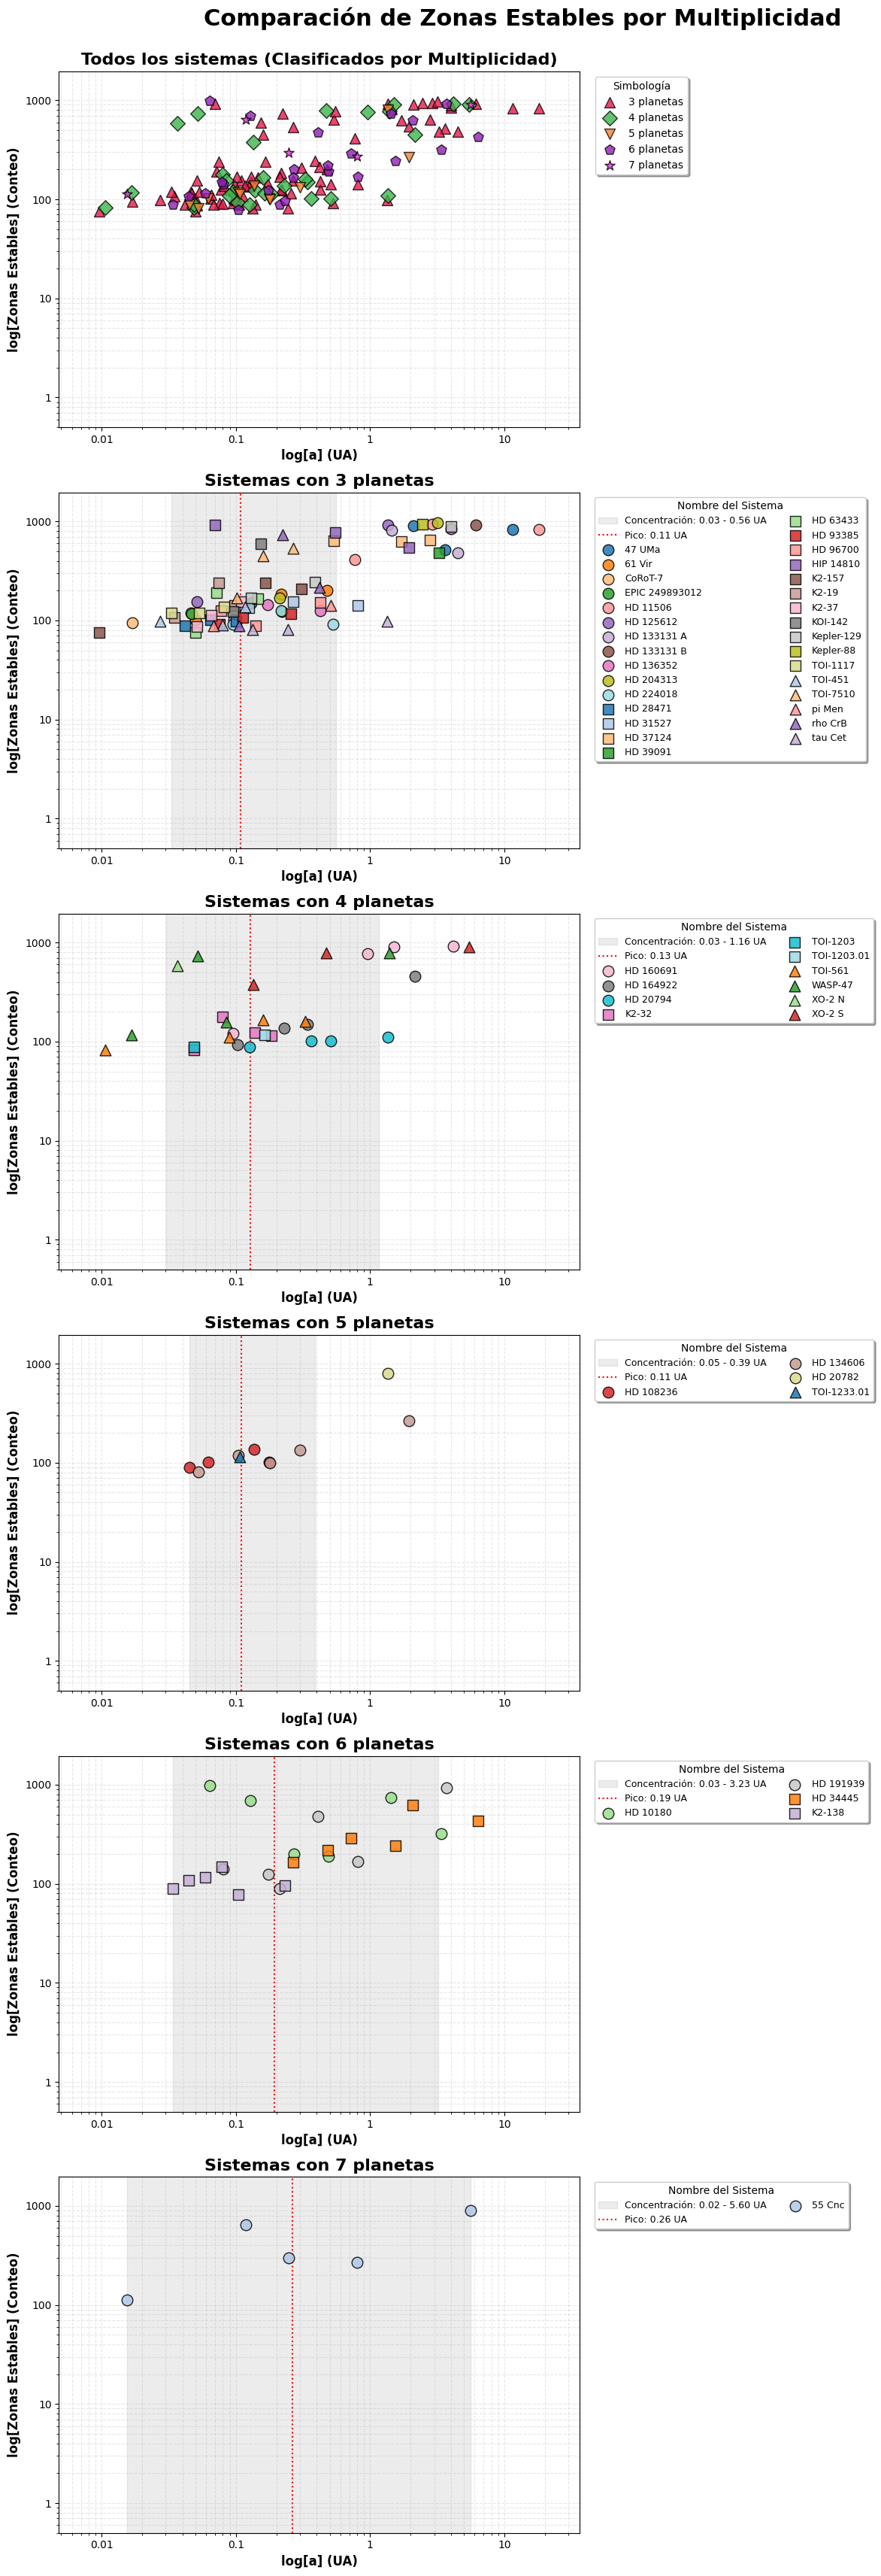

Generando mapa de contornos 2D expandido para: Zonas Estables...


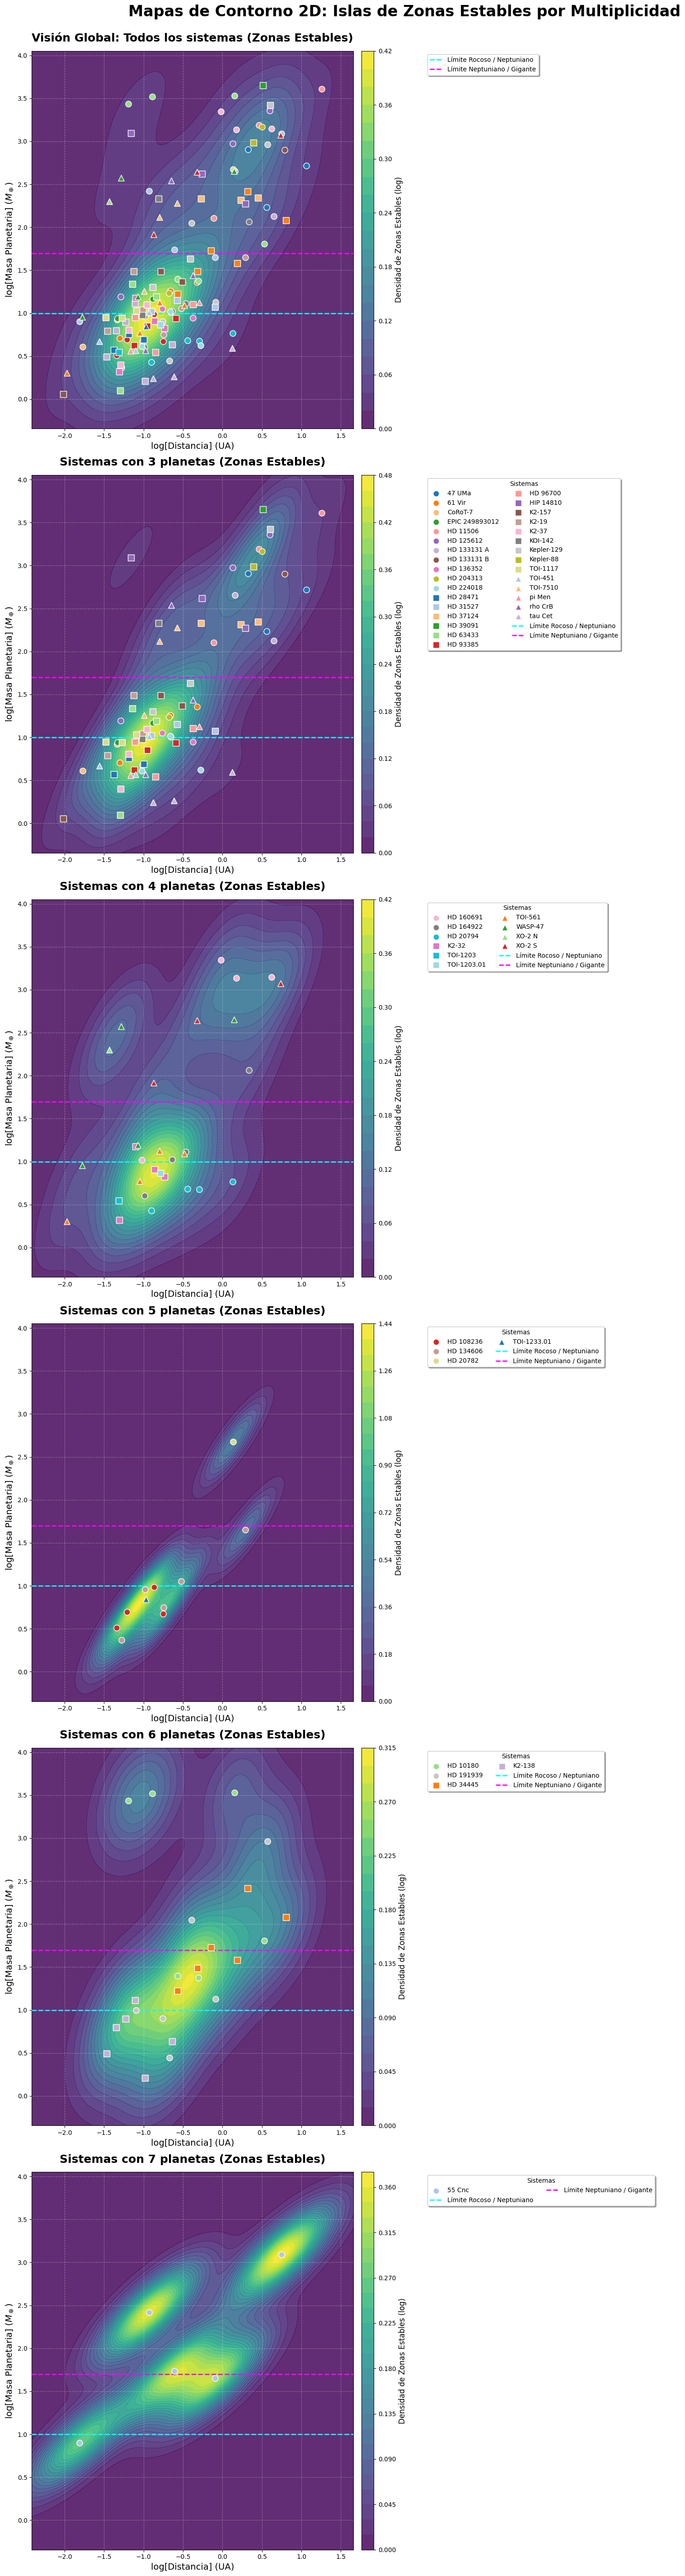

Generando mapa de contornos 2D expandido para: Zonas Inestables...


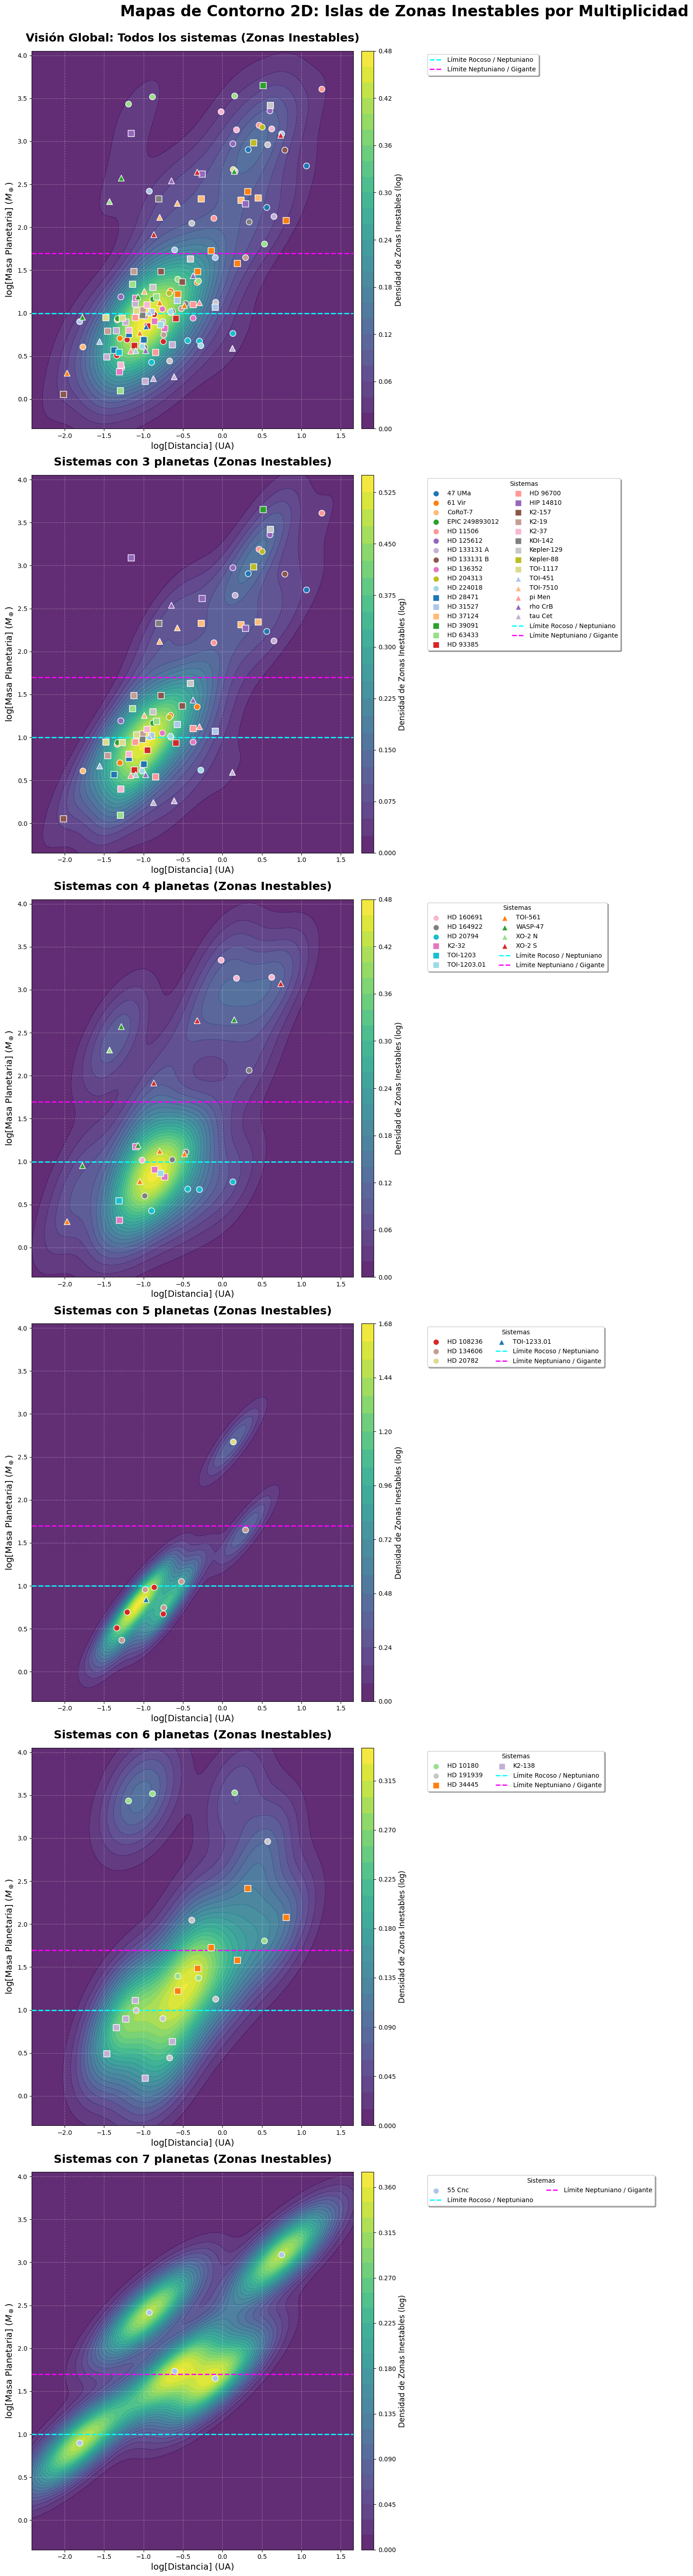

Generando mapa de contornos 2D expandido para: Zonas Colisión m1...
⚠️ No hay suficientes datos válidos (>0) para generar el mapa de Zonas Colisión m1.
Generando mapa de contornos 2D expandido para: Zonas Colisión m2...


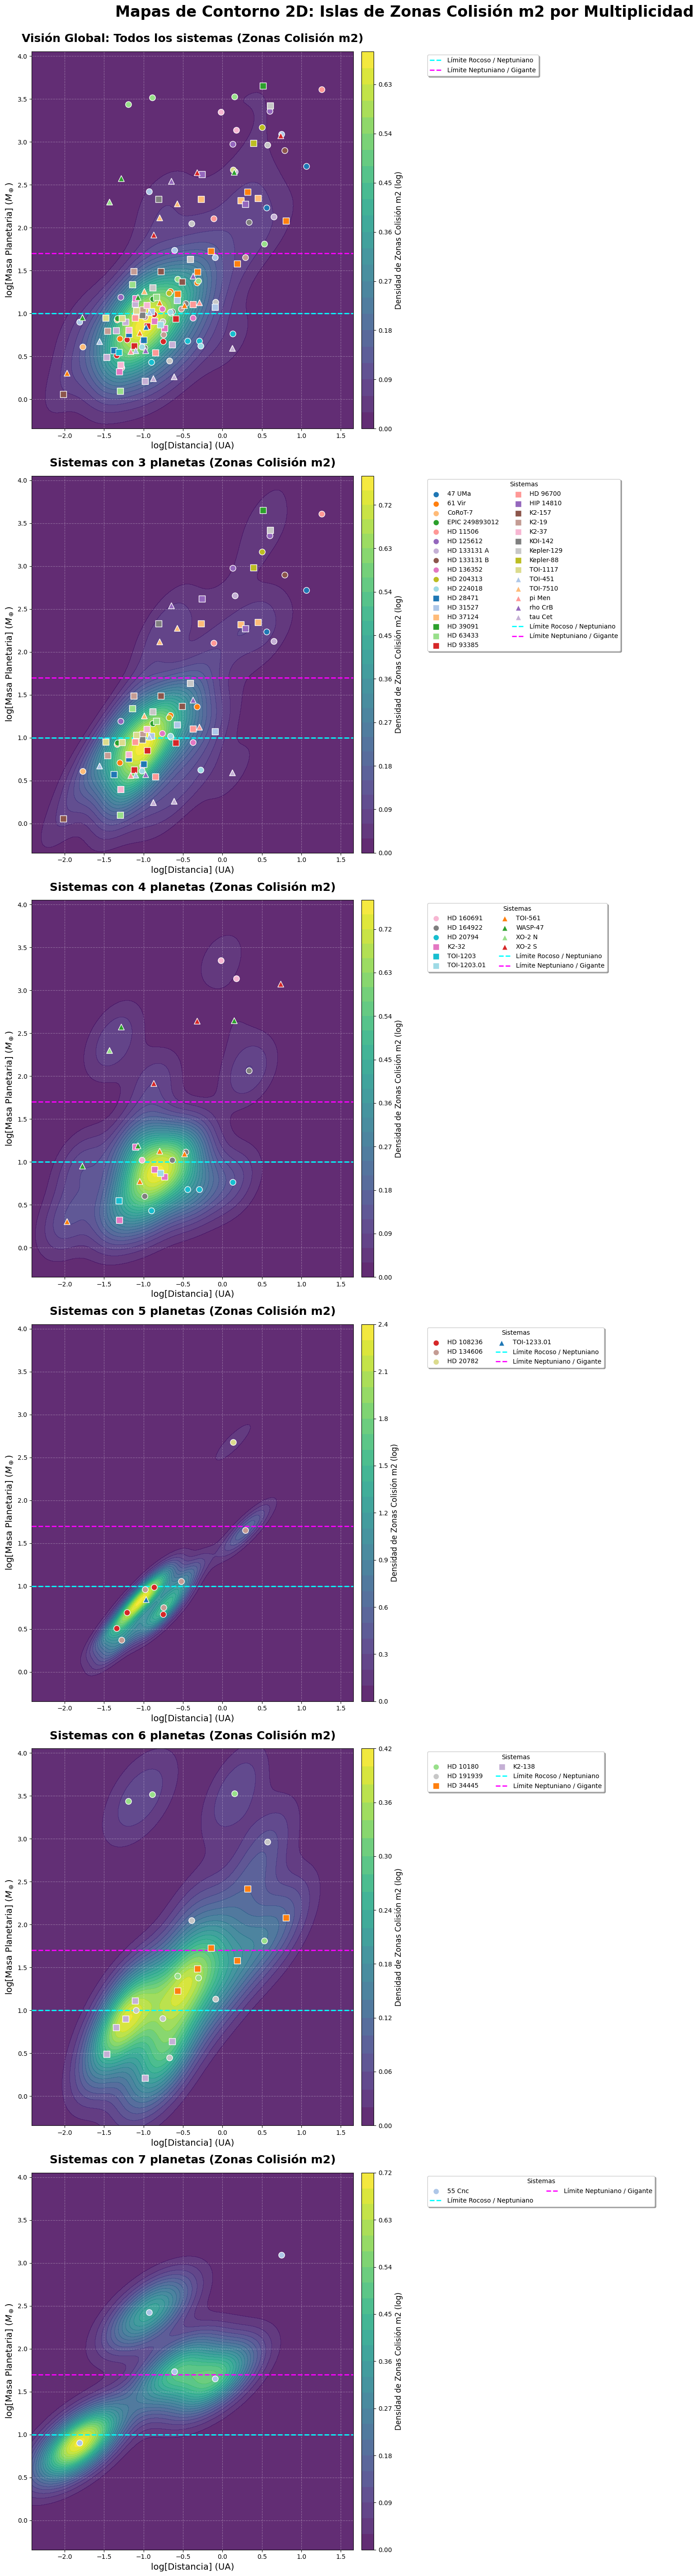

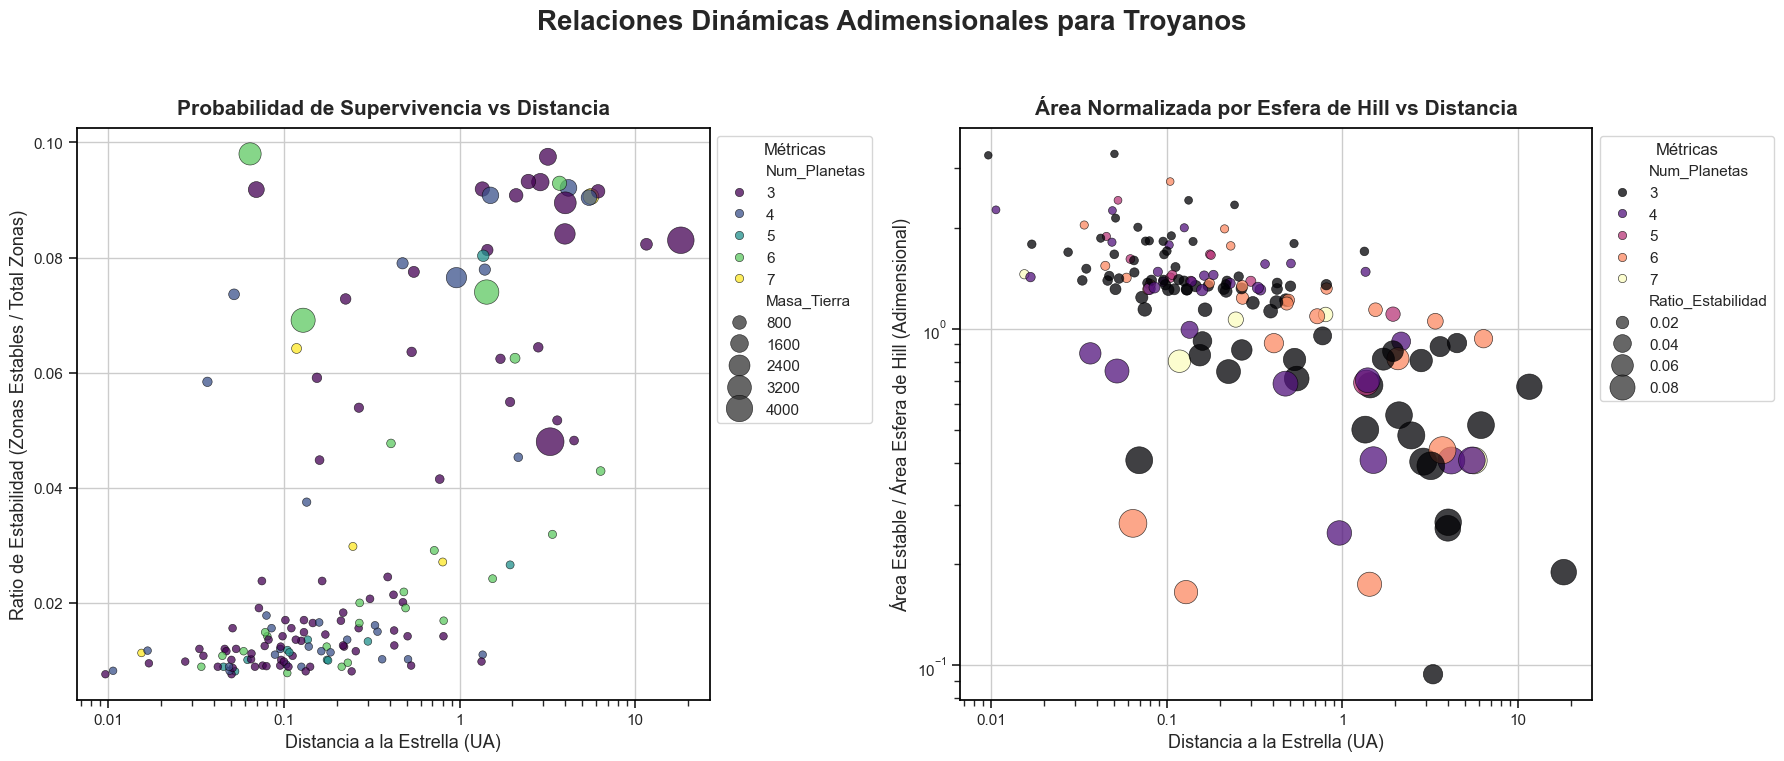


Generando gráfico 3D de Zonas Estables vs Distancia y mu1...


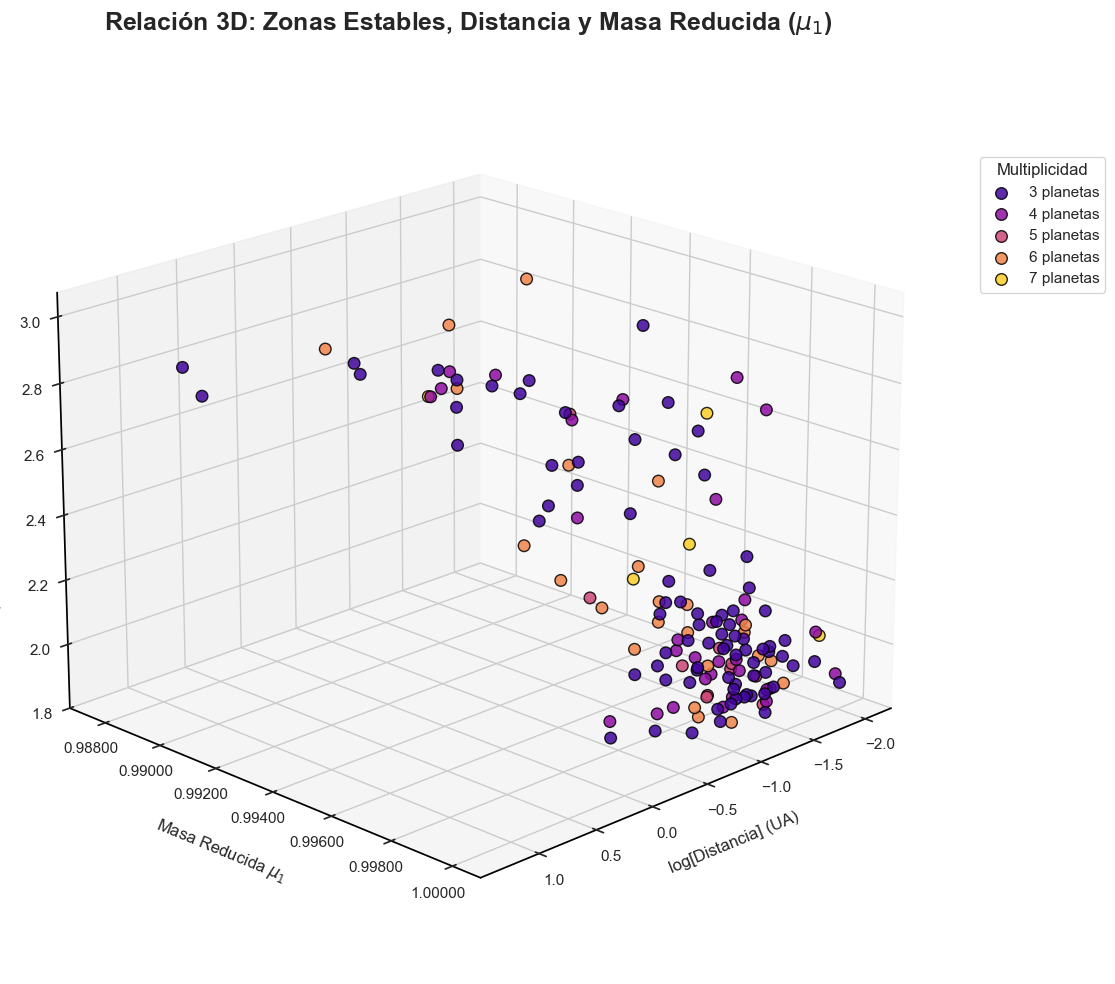

In [9]:
if __name__ == "__main__":
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)

    print("Esperando selección de carpeta en la ventana emergente...")
    DIRECTORIO_RAIZ = filedialog.askdirectory(title="Selecciona la carpeta raíz de resultados")

    if DIRECTORIO_RAIZ:
        # 1. Extraer todos los datos (con arreglo de tildes y m1)
        df_datos = extraer_datos_de_carpetas(DIRECTORIO_RAIZ)
        
        if not df_datos.empty:
            # 2. ACOTAR: Seleccionar solo sistemas con 3 o más planetas
            df_filtrado = df_datos[df_datos['Num_Planetas'] >= 3]
            
            if not df_filtrado.empty:
                print("\nGenerando gráficos de Zonas Estables por multiplicidad...")
                graficar_comparacion_multiplicidad(df_filtrado, DIRECTORIO_RAIZ)
                plot_islands_multi_zonas(df_filtrado, DIRECTORIO_RAIZ)
                graficar_metricas_relativas(df_filtrado, DIRECTORIO_RAIZ)
                plot_3d_zonas_estables_mu1(df_filtrado, DIRECTORIO_RAIZ)
              
            else:
                print("\n⚠️ No quedaron sistemas con 3 o más planetas tras aplicar el filtro.")
        else:
            print("\n❌ No se encontraron datos válidos en la carpeta seleccionada.")
    else:
        print("\n🛑 Operación cancelada por el usuario.")